<a href="https://colab.research.google.com/github/cm06/EMSC2010-W7-P1/blob/main/EMSC2010_W7_P1_NB1_u8257103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W7-P1-NB1

We will test if the air pressures inside and outside the building are the same.

The whole class will collect data using Phyphox (see the *Pressure* option), with each person measuring one inside pressure and one outside pressure. These data will be our measured air pressure samples.

Use the ```PyMC``` code we developed in the previous session (see notebook ```EMSC2010-W7-L1-NB3``` to estimate the posterior distributions for the mean atmospheric pressures inside and outside the building.

In [ ]:
### Add your code here ###

In [ ]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
data_in = np.array([965.784, 965.07, 965.50, 965.993, 965.765, 965.786, 955.604, 965.057, 965.50, 965.930, 965.302, 965.901, 963.623, 965.388, 965.5, 965.910, 965.564, 965.893, 965.735, 965.537]) #inside data
data_out = np.array([966.176, 965.453, 966.25, 966.363, 966.15, 966.085, 965.649, 965.414, 966.172, 965.750, 965.673, 966.257, 964.034, 965.763, 965.88, 966.264, 966.111, 965.864, 966.291, 965.867]) #outside data

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0., 18.]),
 array([955.604 , 956.6429, 957.6818, 958.7207, 959.7596, 960.7985,
        961.8374, 962.8763, 963.9152, 964.9541, 965.993 ]),
 <BarContainer object of 10 artists>)

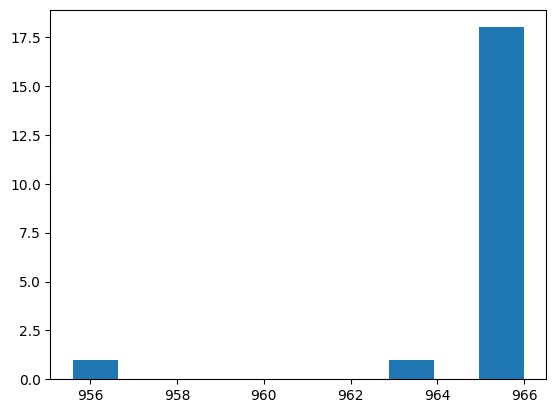

In [ ]:
plt.hist(data_in)

#Histogram of inside data

(array([1., 0., 0., 0., 0., 1., 2., 6., 2., 8.]),
 array([964.034 , 964.2669, 964.4998, 964.7327, 964.9656, 965.1985,
        965.4314, 965.6643, 965.8972, 966.1301, 966.363 ]),
 <BarContainer object of 10 artists>)

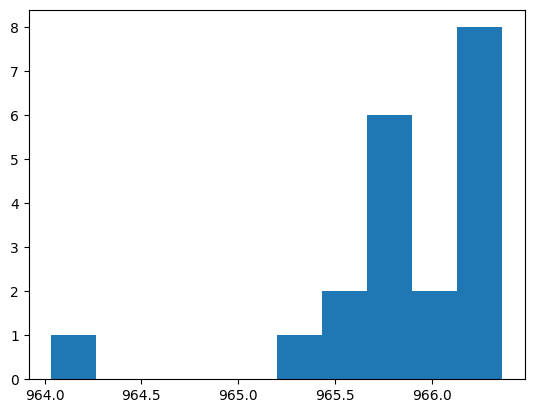

In [ ]:
plt.hist(data_out)

#Histogram of outside data

Think about priors:
- Can't be a negative
- Expect to be around a thousand
- Probably won't be a trillion

Output()

<Axes: title={'center': 'mu'}>

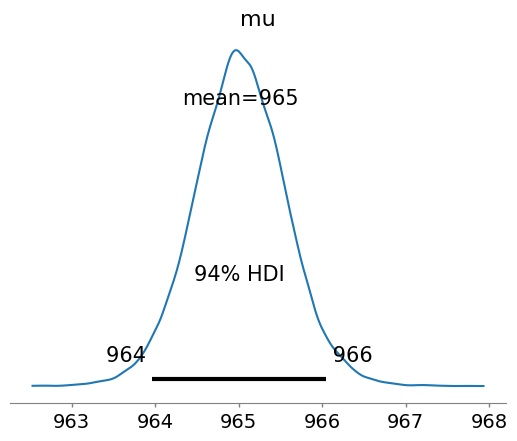

In [ ]:
with pm.Model() as inside_model:

    # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
    mu = pm.Normal("mu", mu=1000, sigma=100)

    # Prior for std of heights — HalfNormal with a standard deviation of 20.
    sigma = pm.HalfNormal("sigma", sigma=20)

    # Likelihood given the data
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=data_in)

    # Obtain 20,000 samples from the posterior
    trace_inside = pm.sample(20000, tune=2000, return_inferencedata=True)

#plot the posterior distribution for the mean
az.plot_posterior(trace_inside, var_names=["mu"])

Output()

<Axes: title={'center': 'mu'}>

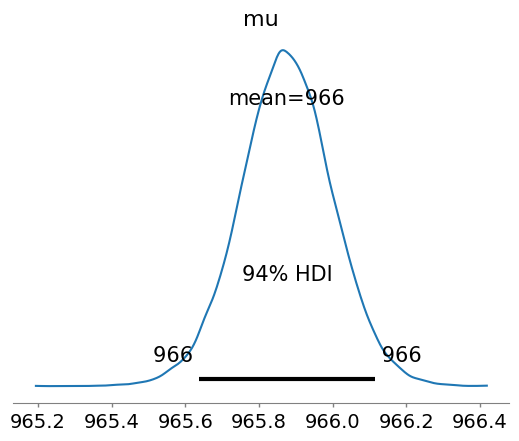

In [ ]:
with pm.Model() as outside_model:

    # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
    mu = pm.Normal("mu", mu=1000, sigma=100)

    # Prior for std of heights — HalfNormal with a standard deviation of 20.
    sigma = pm.HalfNormal("sigma", sigma=20)

    # Likelihood given the data
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=data_out)

    # Obtain 20,000 samples from the posterior
    trace_outside = pm.sample(20000, tune=2000, return_inferencedata=True)

#plot the posterior distribution for the mean
az.plot_posterior(trace_outside, var_names=["mu"])

In [ ]:
# Extract the posterior samples as a numpy array
mu_samples_in = trace_inside.posterior["mu"].values.flatten()
mu_samples_out = trace_outside.posterior["mu"].values.flatten()

Text(0.5, 0, 'Pressure difference inside-outside [hPa]')

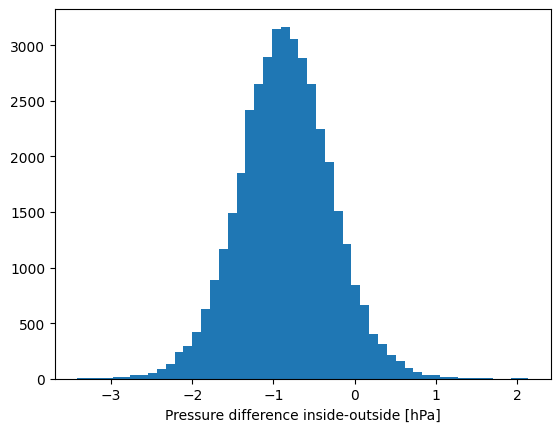

In [ ]:
mu_diff = mu_samples_in - mu_samples_out;
plt.hist(mu_diff,bins=51);
plt.xlabel('Pressure difference inside-outside [hPa]')

In [ ]:
az.hdi(mu_diff,hdi_prob=0.95)

array([-1.94614099,  0.29440121])